In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("All libraries installed successfully!")

All libraries installed successfully!


In [5]:
import pandas as pd

df = pd.read_csv(r"C:/Users/Aryan/OneDrive/Desktop/RAINFALL PROJECT/weatherAUS.csv/weatherAUS.csv")

print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

In [6]:
print(df.shape)

(145460, 23)


In [7]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [9]:
df['RainTomorrow'].isnull().sum()

np.int64(3267)

In [12]:
df = df.dropna(subset=['RainTomorrow'])

In [13]:
print(df.shape)

(142193, 23)


In [14]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No':0,'Yes':1})

print(df['RainTomorrow'].head())

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64


In [15]:
df['RainToday'] = df['RainToday'].map({'No':0,'Yes':1})

print(df['RainToday'].head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: RainToday, dtype: float64


In [16]:
df[['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm']] = \
df[['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm']].fillna(
df[['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm']].mean()
)

In [17]:
df[['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm']].isnull().sum()

MinTemp        0
MaxTemp        0
Rainfall       0
Humidity9am    0
Humidity3pm    0
dtype: int64

In [18]:
features = ['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm','RainToday']

X = df[features]
y = df['RainTomorrow']

print(X.head())
print(y.head())

   MinTemp  MaxTemp  Rainfall  Humidity9am  Humidity3pm  RainToday
0     13.4     22.9       0.6         71.0         22.0        0.0
1      7.4     25.1       0.0         44.0         25.0        0.0
2     12.9     25.7       0.0         38.0         30.0        0.0
3      9.2     28.0       0.0         45.0         16.0        0.0
4     17.5     32.3       1.0         82.0         33.0        0.0
0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64


In [19]:
X.isnull().sum()

MinTemp           0
MaxTemp           0
Rainfall          0
Humidity9am       0
Humidity3pm       0
RainToday      1406
dtype: int64

In [20]:
df['RainToday'] = df['RainToday'].fillna(0)

In [21]:
X = df[features]

print(X.isnull().sum())

MinTemp        0
MaxTemp        0
Rainfall       0
Humidity9am    0
Humidity3pm    0
RainToday      0
dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(113754, 6)
(28439, 6)


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [27]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy*100)

Accuracy = 82.72442772249376


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20796  1302]
 [ 3611  2730]]


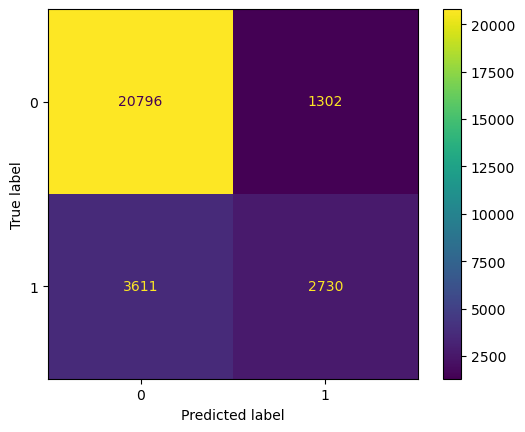

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [31]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
4  Humidity3pm    0.288567
0      MinTemp    0.207313
1      MaxTemp    0.205237
3  Humidity9am    0.160050
2     Rainfall    0.109667
5    RainToday    0.029165


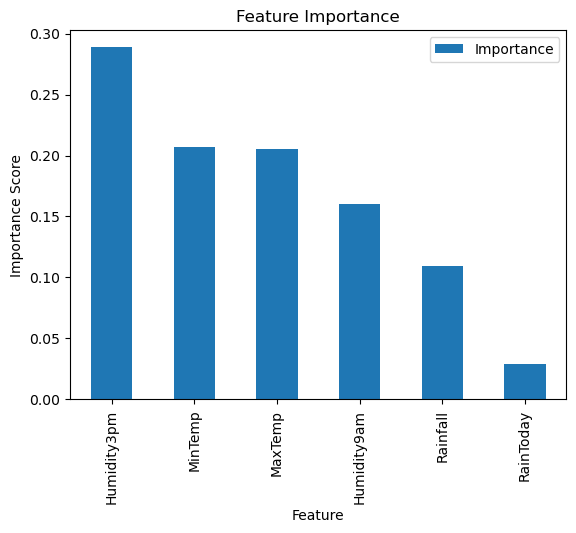

In [32]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.show()

In [33]:
pwd

'C:\\Users\\Aryan'